In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset: MovieLens

In [2]:
ml = pd.read_csv('data_preprocessed/ml-1m_2500.csv')
ml_train = pd.read_csv('data_preprocessed/ml-1m_2500_train.csv')
ml_test = pd.read_csv('data_preprocessed/ml-1m_2500_test.csv')

In [14]:
ml.head()

,prompt,context,gender,age,occupation,target_mid,target_title
0,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Independence Day (ID4) (199...,M,50-55,academic/educator,3022,"General, The (1927)"
1,User profile (audit only):\n- gender: F\n- age...,Watch history:\n1. Renaissance Man (1994)\n2. ...,F,25-34,college/grad student,333,Tommy Boy (1995)
2,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Terms of Endearment (1983)\...,M,25-34,academic/educator,2245,Working Girl (1988)
3,User profile (audit only):\n- gender: M\n- age...,"Watch history:\n1. Spanish Prisoner, The (1997...",M,25-34,academic/educator,1748,Dark City (1998)
4,User profile (audit only):\n- gender: M\n- age...,Watch history:\n1. Shadowlands (1993)\n2. Fabu...,M,56+,writer,3224,Woman in the Dunes (Suna no onna) (1964)


In [16]:
# number of female users in MovieLens
print('number of female users:', len(ml[ml['gender']=='F']))
print('number of male users:', len(ml[ml['gender']=='M']))


number of female users: 597
number of male users: 1903


In [17]:
# number of distinct of occupations
print(len(list(ml['occupation'].drop_duplicates())))

21


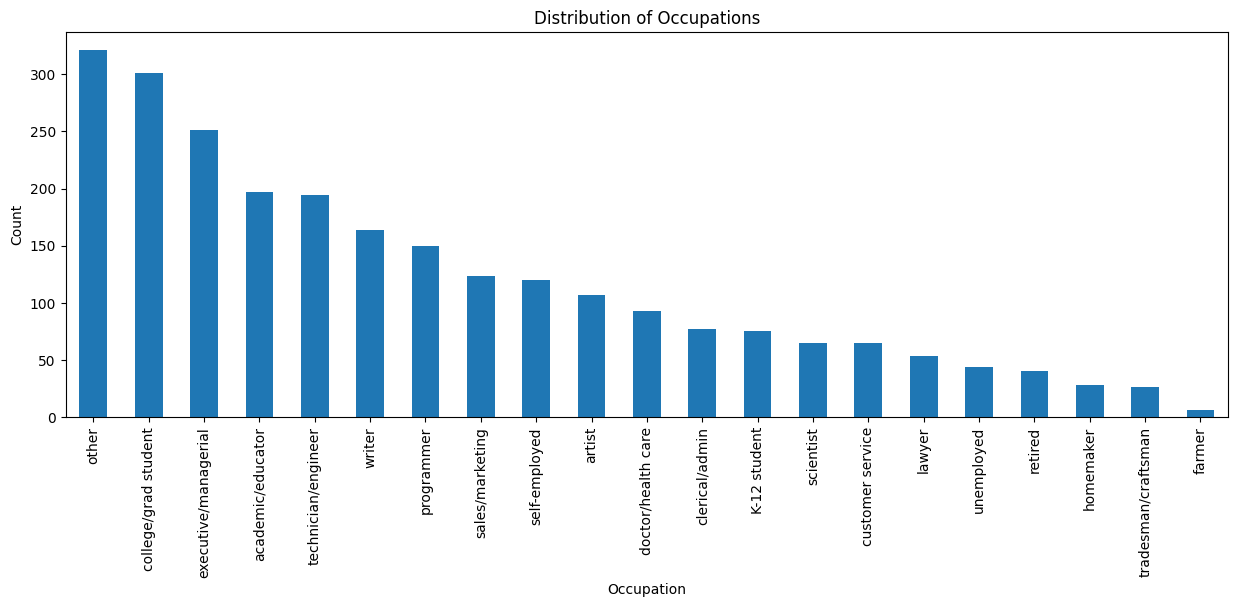

In [18]:
# Bar plot of occupations
counts = ml["occupation"].value_counts()
plt.figure(figsize=(15,5))
counts.plot(kind='bar')
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.title("Distribution of Occupations")
plt.show()

In [19]:
# number of distinct target titles
print(len(list(ml['target_title'].drop_duplicates())))

1297


In [5]:
# number of unique combinations gender-age-occupation
group_counts = ml[['gender', 'age', 'occupation']].value_counts()
group_counts

gender  age       occupation          
M       18-24     college/grad student    151
        25-34     other                   119
                  executive/managerial     89
                  college/grad student     79
                  programmer               74
                                         ... 
F       Under 18  artist                    1
        56+       self-employed             1
                  other                     1
                  sales/marketing           1
M       Under 18  sales/marketing           1
Name: count, Length: 198, dtype: int64

In [43]:
# number of unique combinations gender-age-occupation in calibration set
group_counts_train = ml_train[['gender', 'age', 'occupation']].value_counts()
len(group_counts_train)

168

In [42]:
# number of unique combinations gender-age-occupation in test set
group_counts_test = ml_test[['gender', 'age', 'occupation']].value_counts()
len(group_counts_test)

168

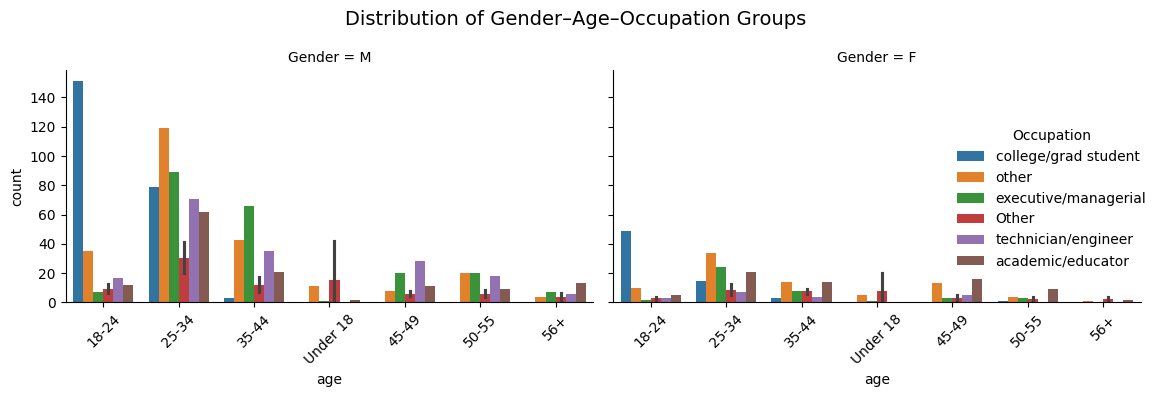

In [ ]:
# distribution 
counts = group_counts.reset_index(name="count")
top_occ = (
    counts.groupby("occupation")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

counts["occupation_plot"] = counts["occupation"].where(
    counts["occupation"].isin(top_occ), "Other"
)

g = sns.catplot(
    data=counts,
    x="age",
    y="count",
    hue="occupation_plot",
    col="gender",
    kind="bar",
    height=4,
    aspect=1.2
)

g.set_xticklabels(rotation=45)
g.set_titles("Gender = {col_name}")
g._legend.set_title("Occupation")
g.fig.suptitle(
    "Distribution of Gender–Age–Occupation Groups",
    fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# distributions of calibration and test sets to show the effect of stratification
print("Number of calibration samples:", len(ml_train))
print("Number of test samples:", len(ml_test))


Number of calibration samples: 1729
Number of test samples: 741


In [ ]:
def group_proportions(df, split_name):
    out = (
        df[["gender", "age", "occupation"]]
        .value_counts()
        .reset_index(name="count")
    )
    out["prop"] = out["count"] / out["count"].sum() # number of samples in group / number of samples in split
    out["split"] = split_name
    return out

train_groups  = group_proportions(ml_train, "Calibration")
test_groups = group_proportions(ml_test, "Test")

plot_df = pd.concat([train_groups, test_groups], ignore_index=True)
plot_df.head()


,gender,age,occupation,count,prop,split
0,M,18-24,college/grad student,106,0.061307,Calibration
1,M,25-34,other,83,0.048005,Calibration
2,M,25-34,executive/managerial,62,0.035859,Calibration
3,M,25-34,college/grad student,55,0.031810,Calibration
4,M,25-34,programmer,52,0.030075,Calibration


In [ ]:
plot_df_age = (
    plot_df
    .groupby(["gender", "age", "split"], as_index=False)["prop"]
    .sum()
)

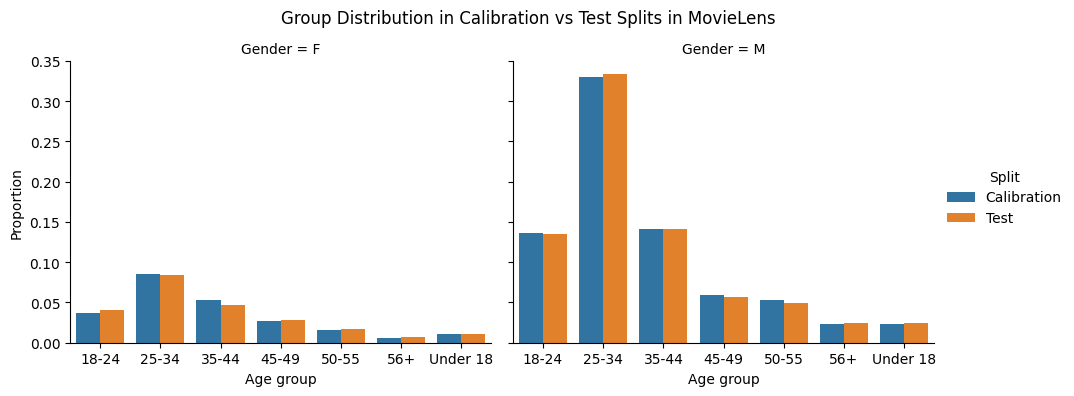

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=plot_df_age,
    x="age",
    y="prop",
    hue="split",
    col="gender",
    kind="bar",
    height=4,
    aspect=1.2
)

g.set_titles("Gender = {col_name}")
g.set_axis_labels("Age group", "Proportion")
g._legend.set_title("Split")

g.fig.suptitle("Group Distribution in Calibration vs Test Splits in MovieLens")
g.fig.subplots_adjust(top=0.85)

plt.show()


### Datset: Amazon